# QUBO Step-by-Step Formulation

This notebook is intentionally independent from `src/quantum/qubo_builder.py`.

The goal is pedagogical: build the QUBO coefficient dictionary term by term so the formulation can be explained in a meeting.

We build:

$$
H_{\text{total}} = H_{\text{energy}} + H_{\text{assign}} + H_{\text{GPU}} + H_{\text{peak}}
$$

The notebook supports two PUE modes:

- `fixed`: fixed or exogenous PUE multiplies IT load.
- `load_dependent`: affine utilization-dependent PUE is used in the energy term.

The load-dependent PUE mode is kept out of the squared peak term because that would create quartic terms, not a plain QUBO.


## 1. Toy Instance and Scenario Knobs

We use a tiny instance so every coefficient can be inspected.

The key switch is `PUE_MODE`:

```python
PUE_MODE = "fixed"
# or
PUE_MODE = "load_dependent"
```

For load-dependent PUE, the energy term uses:

$$
\mathrm{PUE}_t(x) = PUE_{\text{high}} - (PUE_{\text{high}} - PUE_{\text{low}}) \frac{L^{\mathrm{IT}}_t(x)}{L^{\mathrm{IT}}_{\max}}
$$


In [1]:
from __future__ import annotations

import os
from dataclasses import dataclass, field
from itertools import combinations
from math import ceil, log2
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    import dimod
except ImportError:
    dimod = None

try:
    from dwave.samplers import SimulatedAnnealingSampler
except ImportError:
    SimulatedAnnealingSampler = None

jobs = pd.DataFrame([
    {
        "job_id": "j1",
        "duration": 1,
        "earliest_start": 0,
        "latest_start": 1,
        "gpu": 1,
        "power_mw": 0.010,
        "compatible_clusters": ["c_t4"],
    },
    {
        "job_id": "j2",
        "duration": 1,
        "earliest_start": 0,
        "latest_start": 2,
        "gpu": 1,
        "power_mw": 0.015,
        "compatible_clusters": ["c_t4"],
    },
    {
        "job_id": "j3",
        "duration": 1,
        "earliest_start": 0,
        "latest_start": 2,
        "gpu": 1,
        "power_mw": 0.008,
        "compatible_clusters": ["c_v100"],
    },
])

clusters = pd.DataFrame([
    {"cluster_id": "c_t4", "gpu_capacity": 1},
    {"cluster_id": "c_v100", "gpu_capacity": 1},
])

hours = [0, 1, 2]
delta_t = 1.0

# Effective price already represents the simplified QUBO view of energy timing.
price = {0: 30.0, 1: 100.0, 2: 40.0}

# PUE mode: "fixed" or "load_dependent".
PUE_MODE = "fixed"

# Fixed/exogenous PUE profile.
pue = {0: 1.20, 1: 1.20, 2: 1.20}

# Load-dependent PUE calibration.
pue_high = 1.35
pue_low = 1.15
it_load_max = jobs["power_mw"].sum()

weights = {
    "assignment": 200.0,
    "gpu_capacity": 80.0,
    "peak": 5000.0,
}

jobs


,job_id,duration,earliest_start,latest_start,gpu,power_mw,compatible_clusters
0,j1,1,0,1,1,0.010,[c_t4]
1,j2,1,0,2,1,0.015,[c_t4]
2,j3,1,0,2,1,0.008,[c_v100]


## 2. Basic QUBO Data Structure

A QUBO has the form:

$$
H(z) = q_0 + \sum_i q_i z_i + \sum_{i < j} q_{ij} z_i z_j
$$

The `QuboState` object stores the coefficients and variable metadata. Every function receives this state explicitly and returns or mutates it explicitly; no function depends on hidden global QUBO variables.

The most important helper is `add_squared_penalty`. It implements a generic squared equality penalty:

$$
H_{\text{penalty}} = \lambda \left( \sum_{r \in R} a_r z_r - b \right)^2
$$

Expanding the square:

$$
\begin{aligned}
\lambda \left( \sum_{r \in R} a_r z_r - b \right)^2
&= \lambda \left[
\left(\sum_{r \in R} a_r z_r\right)^2
- 2b \sum_{r \in R} a_r z_r
+ b^2
\right] \\
&= \lambda \left[
\sum_{r \in R} a_r^2 z_r^2
+ \sum_{r \in R}\sum_{q \in R: q \ne r} a_r a_q z_r z_q
- 2b \sum_{r \in R} a_r z_r
+ b^2
\right]
\end{aligned}
$$

Because QUBO variables are binary, $z_r^2 = z_r$. Therefore:

$$
H_{\text{penalty}} =
\lambda b^2
+ \sum_{r \in R} \lambda (a_r^2 - 2ba_r) z_r
+ \sum_{r \in R}\sum_{q \in R: q \ne r} \lambda a_r a_q z_r z_q
$$

This formula writes the quadratic part as all ordered pairs with $q \ne r$. That is mathematically fine, but it counts each interaction twice: once as $(r,q)$ and once as $(q,r)$. Since a QUBO stores one coefficient per unordered pair, the code loops over each unordered pair only once and adds the combined coefficient:

$$
\lambda a_r a_q + \lambda a_q a_r = 2\lambda a_r a_q
$$

So the implementation does the same expansion as:

- `state.offset += weight * rhs * rhs`
- one loop over every variable: `add_linear(..., weight * (ai * ai - 2 * rhs * ai))`
- one loop over every unordered pair of different variables: `add_quadratic(..., 2 * weight * ai * aj)`

So every squared penalty is converted into QUBO coefficients by expanding the square and using the binary identity $z^2=z$.


In [2]:
@dataclass
class QuboState:
    """Small didactic QUBO container."""

    linear: dict[int, float] = field(default_factory=dict)
    quadratic: dict[tuple[int, int], float] = field(default_factory=dict)
    offset: float = 0.0
    variables: list[dict] = field(default_factory=list)


def add_linear(state: QuboState, i: int, coeff: float) -> None:
    """Add q_i z_i to the QUBO."""
    if abs(coeff) > 1e-12:
        state.linear[i] = state.linear.get(i, 0.0) + float(coeff)


def add_quadratic(state: QuboState, i: int, j: int, coeff: float) -> None:
    """Add q_ij z_i z_j to the QUBO."""
    if abs(coeff) <= 1e-12:
        return
    if i == j:
        # Binary identity: z_i^2 = z_i.
        add_linear(state, i, coeff)
        return
    key = (i, j) if i < j else (j, i)
    state.quadratic[key] = state.quadratic.get(key, 0.0) + float(coeff)


def add_squared_penalty(state: QuboState, terms: dict[int, float], rhs: float, weight: float) -> None:
    """Add weight * (sum_i terms[i] z_i - rhs)^2."""
    state.offset += weight * rhs * rhs
    for i, ai in terms.items():
        add_linear(state, i, weight * (ai * ai - 2.0 * rhs * ai))
    for i, j in combinations(terms, 2):
        add_quadratic(state, i, j, 2.0 * weight * terms[i] * terms[j])


def qubo_summary(state: QuboState) -> dict:
    """Return a compact summary of the current QUBO."""
    return {
        "variables": len(state.variables),
        "linear_terms": len(state.linear),
        "quadratic_terms": len(state.quadratic),
        "offset": state.offset,
    }

state = QuboState()
qubo_summary(state)

{'variables': 0, 'linear_terms': 0, 'quadratic_terms': 0, 'offset': 0.0}

## 3. Assignment Variables

Create one variable per feasible scheduling option:

$$
x_{i,k,s} = 1
$$

if job $i$ starts on cluster $k$ at start slot $s$.

Compatibility is represented directly as a job-cluster input relation:

$$
C_{i,k} \in \{0,1\}
$$

where $C_{i,k} = 1$ means job $i$ can run on cluster $k$. In the notebook data this is stored as a `compatible_clusters` list inside each job row.

A variable is created only if:

$$
C_{i,k} = 1
$$

So invalid job-cluster options never enter the Hamiltonian. GPU type, software stack, data locality, or business rules can all be used upstream to build `compatible_clusters`, but the QUBO only sees the final compatibility relation.


In [3]:
def feasible_starts(job: pd.Series) -> list[int]:
    """Return feasible start slots for one job."""
    return list(range(int(job.earliest_start), int(job.latest_start) + 1))


def is_cluster_compatible(job: pd.Series, cluster: pd.Series) -> bool:
    """Return whether a job can run on a cluster according to C_{i,k}."""
    return str(cluster.cluster_id) in set(job.compatible_clusters)


def add_assignment_variables(state: QuboState, jobs_df: pd.DataFrame, clusters_df: pd.DataFrame) -> None:
    """Create x_{i,k,s} variables only for compatible job-cluster pairs."""
    for _, job in jobs_df.iterrows():
        for _, cluster in clusters_df.iterrows():
            if not is_cluster_compatible(job, cluster):
                continue
            for start in feasible_starts(job):
                state.variables.append({
                    "type": "assignment",
                    "job_id": job.job_id,
                    "cluster_id": cluster.cluster_id,
                    "start": int(start),
                    "duration": int(job.duration),
                    "gpu": float(job.gpu),
                    "power_mw": float(job.power_mw),
                })

add_assignment_variables(state, jobs, clusters)
assignment_variable_count = len(state.variables)
pd.DataFrame(state.variables)

,type,job_id,cluster_id,start,duration,gpu,power_mw
0,assignment,j1,c_t4,0,1,1.0,0.010
1,assignment,j1,c_t4,1,1,1.0,0.010
2,assignment,j2,c_t4,0,1,1.0,0.015
3,assignment,j2,c_t4,1,1,1.0,0.015
4,assignment,j2,c_t4,2,1,1.0,0.015
5,assignment,j3,c_v100,0,1,1.0,0.008
6,assignment,j3,c_v100,1,1,1.0,0.008
7,assignment,j3,c_v100,2,1,1.0,0.008


## 4. Activity Coefficient

The activity coefficient is precomputed data, not a decision variable:

$$
a_{i,s,t} =
\begin{cases}
1, & s \le t < s + d_i \\
0, & \text{otherwise}
\end{cases}
$$


In [4]:
def is_active(start: int, duration: int, hour: int) -> bool:
    """Return whether a job starting at `start` is active at `hour`."""
    return start <= hour < start + duration


def activity_table(state: QuboState, hours: list[int]) -> pd.DataFrame:
    """Build a readable activity table for assignment variables."""
    rows = []
    for idx, var in enumerate(state.variables):
        if var["type"] != "assignment":
            continue
        for t in hours:
            rows.append({
                "var": idx,
                "job": var["job_id"],
                "start": var["start"],
                "hour": t,
                "active": int(is_active(var["start"], var["duration"], t)),
            })
    return pd.DataFrame(rows)

activity_table(state, hours).head(20)

,var,job,start,hour,active
0,0,j1,0,0,1
1,0,j1,0,1,0
2,0,j1,0,2,0
3,1,j1,1,0,0
4,1,j1,1,1,1
5,1,j1,1,2,0
6,2,j2,0,0,1
7,2,j2,0,1,0
8,2,j2,0,2,0
9,3,j2,1,0,0


### 4.1 D-Wave Simulator and Validation Helpers

The next helper functions are not part of any specific Hamiltonian term. They convert the didactic QUBO into a `dimod.BinaryQuadraticModel`, solve it with D-Wave Ocean's simulated annealing sampler (`dwave.samplers.SimulatedAnnealingSampler`), and validate the decoded schedule after each progressive modeling step.

This uses a D-Wave-style sampler interface over the BQM rather than exhaustive search over all binary strings.


In [5]:
def clone_state_with_same_variables(source: QuboState) -> QuboState:
    """Create a clean QUBO state with the same variable metadata and no coefficients."""
    return QuboState(variables=[dict(variable) for variable in source.variables])


def qubo_energy(state: QuboState, sample: dict[int, int]) -> float:
    """Evaluate QUBO energy for one binary sample."""
    value = state.offset
    value += sum(coeff * sample.get(i, 0) for i, coeff in state.linear.items())
    value += sum(coeff * sample.get(i, 0) * sample.get(j, 0) for (i, j), coeff in state.quadratic.items())
    return float(value)


def to_dimod_bqm(state: QuboState):
    """Convert the didactic QUBO into a dimod BinaryQuadraticModel."""
    if dimod is None:
        raise ImportError("dimod is not installed")

    bqm = dimod.BinaryQuadraticModel({}, {}, state.offset, dimod.BINARY)
    for i, coeff in state.linear.items():
        bqm.add_variable(i, coeff)
    for (i, j), coeff in state.quadratic.items():
        bqm.add_interaction(i, j, coeff)
    return bqm


def decode_schedule(state: QuboState, sample: dict[int, int]) -> pd.DataFrame:
    """Decode selected assignment variables into a schedule table."""
    rows = []
    for idx, bit in sample.items():
        if bit != 1:
            continue
        var = state.variables[idx]
        if var["type"] == "assignment":
            rows.append({"var": idx, **var})
    columns = ["var", "type", "job_id", "cluster_id", "start", "duration", "gpu", "power_mw"]
    return pd.DataFrame(rows, columns=columns)


def solve_with_dwave_simulator(state: QuboState, reads: int = 5000, seed: int = 42) -> dict:
    """Solve the current QUBO with D-Wave Ocean's simulated annealing sampler."""
    if SimulatedAnnealingSampler is None:
        raise ImportError("dwave.samplers is not installed; install dwave-samplers to run the D-Wave simulator")

    bqm = to_dimod_bqm(state)
    sampleset = SimulatedAnnealingSampler().sample(
        bqm,
        num_reads=reads,
        seed=seed,
    )
    best = sampleset.first
    sample = {int(variable): int(value) for variable, value in best.sample.items()}
    return {
        "energy": float(best.energy),
        "sample": sample,
        "schedule": decode_schedule(state, sample),
        "sampleset": sampleset,
        "solver": "dwave.samplers.SimulatedAnnealingSampler",
        "reads": reads,
        "seed": seed,
    }


def assignment_validation(schedule_df: pd.DataFrame, jobs_df: pd.DataFrame) -> pd.DataFrame:
    """Report how many times each job appears in the decoded schedule."""
    assigned = schedule_df["job_id"].value_counts() if not schedule_df.empty else pd.Series(dtype=int)
    rows = []
    for job_id in jobs_df["job_id"]:
        count = int(assigned.get(job_id, 0))
        rows.append({
            "job_id": job_id,
            "assignments": count,
            "valid_exactly_once": count == 1,
        })
    return pd.DataFrame(rows)


def gpu_usage_validation(schedule_df: pd.DataFrame, clusters_df: pd.DataFrame, hours: list[int]) -> pd.DataFrame:
    """Report GPU usage and capacity violations by cluster and time."""
    rows = []
    for cluster in clusters_df.itertuples(index=False):
        for t in hours:
            used = 0.0
            if not schedule_df.empty:
                for assignment in schedule_df.itertuples(index=False):
                    if assignment.cluster_id != cluster.cluster_id:
                        continue
                    if is_active(int(assignment.start), int(assignment.duration), int(t)):
                        used += float(assignment.gpu)
            capacity = float(cluster.gpu_capacity)
            rows.append({
                "cluster_id": cluster.cluster_id,
                "hour": t,
                "gpu_used": used,
                "gpu_capacity": capacity,
                "gpu_violation": max(0.0, used - capacity),
            })
    return pd.DataFrame(rows)


def solve_and_validate(label: str, state: QuboState, jobs_df: pd.DataFrame, clusters_df: pd.DataFrame, hours: list[int]) -> dict:
    """Solve the current tiny QUBO with the D-Wave simulator and show validation tables."""
    result = solve_with_dwave_simulator(state)
    schedule = result["schedule"]
    assignment_check = assignment_validation(schedule, jobs_df)
    gpu_check = gpu_usage_validation(schedule, clusters_df, hours)
    summary = {
        "stage": label,
        "solver": result["solver"],
        "reads": result["reads"],
        "energy": result["energy"],
        **qubo_summary(state),
        "scheduled_jobs": 0 if schedule.empty else int(schedule["job_id"].nunique()),
        "total_assignments": len(schedule),
        "assignment_violations": int((~assignment_check["valid_exactly_once"]).sum()),
        "gpu_violation_total": float(gpu_check["gpu_violation"].sum()),
    }
    display(pd.DataFrame([summary]))
    display(schedule)
    display(assignment_check)
    display(gpu_check)
    return {
        **result,
        "summary": summary,
        "assignment_check": assignment_check,
        "gpu_check": gpu_check,
    }


## 5. Energy Cost Term: Cost-Only Validation

We start with only the energy cost term.

Fixed PUE:

$$
H_{\text{energy}}^{\text{PUE-fixed}} = \sum_{i,k,s} E_{i,k,s} x_{i,k,s}
$$

where:

$$
E_{i,k,s} = \sum_t c_t \Delta t \, \mathrm{PUE}_t \, p_i \, a_{i,s,t}
$$

This is purely linear: every possible assignment variable receives the energy cost it would create if selected.

Load-dependent PUE energy:

$$
H_{\text{facility}} = \sum_t c_t \Delta t \left[ PUE_{\text{high}} L^{\mathrm{IT}}_t(x) - \frac{PUE_{\text{high}} - PUE_{\text{low}}}{L^{\mathrm{IT}}_{\max}} \left(L^{\mathrm{IT}}_t(x)\right)^2 \right]
$$

with:

$$
L^{\mathrm{IT}}_t(x) = \sum_{i,k,s} p_i a_{i,s,t} x_{i,k,s}
$$

The first part is linear. The second part is quadratic because $L^{\mathrm{IT}}_t(x)$ is a sum of binary variables multiplied by constants. If:

$$
\alpha = \frac{PUE_{\text{high}} - PUE_{\text{low}}}{L^{\mathrm{IT}}_{\max}}
$$

then for one time slot:

$$
- c_t \Delta t\, \alpha \left(L^{\mathrm{IT}}_t(x)\right)^2
= - c_t \Delta t\, \alpha
\left[
\sum_r \ell_r^2 x_r + 2\sum_{r<q}\ell_r\ell_q x_r x_q
\right]
$$

where $\ell_r = p_i a_{i,s,t}$ for assignment option $r=(i,k,s)$.

The first validation is deliberately simple:

> If we include only positive energy cost and no assignment penalty, the optimal solution should schedule no jobs.

That is expected. The cost term prices scheduled work, but it does not force work to happen.


In [6]:
def active_assignment_terms(state: QuboState, hours: list[int], hour: int, coefficient_field: str) -> dict[int, float]:
    """Return coefficients for assignment variables active in one hour."""
    terms = {}
    for idx, var in enumerate(state.variables):
        if var["type"] != "assignment":
            continue
        if is_active(var["start"], var["duration"], hour):
            terms[idx] = float(var[coefficient_field])
    return terms


def add_energy_cost(
    state: QuboState,
    hours: list[int],
    price: dict[int, float],
    delta_t: float,
    pue_mode: str,
    fixed_pue: dict[int, float] | None = None,
    pue_high: float | None = None,
    pue_low: float | None = None,
    it_load_max: float | None = None,
) -> None:
    """Add either fixed-PUE or load-dependent-PUE energy cost."""
    if pue_mode == "fixed":
        if fixed_pue is None:
            raise ValueError("fixed_pue is required when pue_mode='fixed'")
        for t in hours:
            active_power = active_assignment_terms(state, hours, t, "power_mw")
            for idx, power_mw in active_power.items():
                add_linear(state, idx, price[t] * delta_t * fixed_pue[t] * power_mw)
        return

    if pue_mode == "load_dependent":
        if pue_high is None or pue_low is None or it_load_max is None:
            raise ValueError("pue_high, pue_low, and it_load_max are required for load-dependent PUE")
        beta = pue_high - pue_low
        for t in hours:
            active_power = active_assignment_terms(state, hours, t, "power_mw")

            # Linear part: c_t dt PUE_high L_t.
            for idx, power_mw in active_power.items():
                add_linear(state, idx, price[t] * delta_t * pue_high * power_mw)

            # Quadratic part: - c_t dt beta / Lmax * L_t^2.
            factor = -price[t] * delta_t * beta / it_load_max
            for idx, power_mw in active_power.items():
                add_linear(state, idx, factor * power_mw * power_mw)
            for i, j in combinations(active_power, 2):
                add_quadratic(state, i, j, 2.0 * factor * active_power[i] * active_power[j])
        return

    raise ValueError("pue_mode must be 'fixed' or 'load_dependent'")

state = clone_state_with_same_variables(state)
add_energy_cost(
    state,
    hours=hours,
    price=price,
    delta_t=delta_t,
    pue_mode=PUE_MODE,
    fixed_pue=pue,
    pue_high=pue_high,
    pue_low=pue_low,
    it_load_max=it_load_max,
)

cost_only_result = solve_and_validate("1_cost_only", state, jobs, clusters, hours)


,stage,solver,reads,energy,variables,linear_terms,quadratic_terms,offset,scheduled_jobs,total_assignments,assignment_violations,gpu_violation_total
0,1_cost_only,dwave.samplers.SimulatedAnnealingSampler,5000,-4.440892e-16,8,8,0,0.0,0,0,3,0.0


,var,type,job_id,cluster_id,start,duration,gpu,power_mw


,job_id,assignments,valid_exactly_once
0,j1,0,False
1,j2,0,False
2,j3,0,False


,cluster_id,hour,gpu_used,gpu_capacity,gpu_violation
0,c_t4,0,0.0,1.0,0.0
1,c_t4,1,0.0,1.0,0.0
2,c_t4,2,0.0,1.0,0.0
3,c_v100,0,0.0,1.0,0.0
4,c_v100,1,0.0,1.0,0.0
5,c_v100,2,0.0,1.0,0.0


In [7]:
pd.DataFrame([{"var": i, "linear_coeff": coeff, **state.variables[i]} for i, coeff in sorted(state.linear.items())])

,var,linear_coeff,type,job_id,cluster_id,start,duration,gpu,power_mw
0,0,0.360,assignment,j1,c_t4,0,1,1.0,0.010
1,1,1.200,assignment,j1,c_t4,1,1,1.0,0.010
2,2,0.540,assignment,j2,c_t4,0,1,1.0,0.015
3,3,1.800,assignment,j2,c_t4,1,1,1.0,0.015
4,4,0.720,assignment,j2,c_t4,2,1,1.0,0.015
5,5,0.288,assignment,j3,c_v100,0,1,1.0,0.008
6,6,0.960,assignment,j3,c_v100,1,1,1.0,0.008
7,7,0.384,assignment,j3,c_v100,2,1,1.0,0.008


## 6. Assignment Constraint: Force Every Job Once

Each job must be assigned exactly once:

$$
\sum_{(k,s) \in \mathcal{A}_i} x_{i,k,s} = 1
$$

where $\mathcal{A}_i$ is the set of feasible cluster-start options for job $i$.

QUBO penalty:

$$
H_{\text{assign}} = \lambda_A \sum_i \left( \sum_{(k,s) \in \mathcal{A}_i} x_{i,k,s} - 1 \right)^2
$$

For one job, define $R_i=\mathcal{A}_i$ and $z_r=x_{i,k,s}$ for each option $r=(k,s)$. This is the generic squared penalty with $a_r=1$ and $b=1$:

$$
\lambda_A \left( \sum_{r \in R_i} z_r - 1 \right)^2
$$

Expansion:

$$
\begin{aligned}
\lambda_A \left( \sum_{r \in R_i} z_r - 1 \right)^2
&= \lambda_A \left[
\left(\sum_{r \in R_i} z_r\right)^2
-2\sum_{r \in R_i} z_r
+1
\right] \\
&= \lambda_A \left[
\sum_{r \in R_i} z_r^2
+2\sum_{r<q}z_rz_q
-2\sum_{r \in R_i} z_r
+1
\right] \\
&= \lambda_A \left[
1
-\sum_{r \in R_i} z_r
+2\sum_{r<q}z_rz_q
\right]
\end{aligned}
$$

The last step uses $z_r^2=z_r$.

So the coefficients added by `add_squared_penalty(..., rhs=1, weight=lambda_A)` are:

- offset: $+\lambda_A$
- linear coefficient for each assignment option of the job: $-\lambda_A$
- quadratic coefficient between every pair of different options of the same job: $+2\lambda_A$

Interpretation:

- selecting zero options gives penalty $\lambda_A$
- selecting one option gives penalty $0$
- selecting two options gives penalty $\lambda_A$
- selecting more than two options gives an even larger penalty

Validation expectation:

> Once this term is added, every job should appear exactly once. Because GPU capacity is not active yet, several jobs may still choose the same cheap time slot even if that overloads a cluster.


In [8]:
def add_assignment_penalty(state: QuboState, jobs_df: pd.DataFrame, weight: float) -> None:
    """Add one-hot assignment penalties, one job at a time."""
    for job_id in jobs_df["job_id"]:
        terms = {
            idx: 1.0
            for idx, var in enumerate(state.variables)
            if var["type"] == "assignment" and var["job_id"] == job_id
        }
        add_squared_penalty(state, terms, rhs=1.0, weight=weight)

add_assignment_penalty(state, jobs, weights["assignment"])
assignment_result = solve_and_validate("2_cost_plus_assignment", state, jobs, clusters, hours)


,stage,solver,reads,energy,variables,linear_terms,quadratic_terms,offset,scheduled_jobs,total_assignments,assignment_violations,gpu_violation_total
0,2_cost_plus_assignment,dwave.samplers.SimulatedAnnealingSampler,5000,1.188,8,8,7,600.0,3,3,0,1.0


,var,type,job_id,cluster_id,start,duration,gpu,power_mw
0,0,assignment,j1,c_t4,0,1,1.0,0.010
1,2,assignment,j2,c_t4,0,1,1.0,0.015
2,5,assignment,j3,c_v100,0,1,1.0,0.008


,job_id,assignments,valid_exactly_once
0,j1,1,True
1,j2,1,True
2,j3,1,True


,cluster_id,hour,gpu_used,gpu_capacity,gpu_violation
0,c_t4,0,2.0,1.0,1.0
1,c_t4,1,0.0,1.0,0.0
2,c_t4,2,0.0,1.0,0.0
3,c_v100,0,1.0,1.0,0.0
4,c_v100,1,0.0,1.0,0.0
5,c_v100,2,0.0,1.0,0.0


## 7. GPU Capacity Constraint With Binary Slack: Remove Overloads

GPU demand per cluster and time:

$$
D^G_{k,t}(x) = \sum_i \sum_s g_i a_{i,s,t} x_{i,k,s}
$$

where:

- $g_i$ is the number of GPUs required by job $i$
- $a_{i,s,t}$ is precomputed and equals 1 if a job starting at $s$ is active at time $t$
- only variables assigned to cluster $k$ contribute to $D^G_{k,t}(x)$

The original inequality is:

$$
D^G_{k,t}(x) \le G_k
$$

QUBO handles this by adding an unused-capacity slack variable:

$$
D^G_{k,t}(x) + Y_{k,t} = G_k
$$

The slack is binary encoded:

$$
Y_{k,t} = \sum_{b=0}^{B_k-1} 2^b y_{k,t,b}
$$

So the implemented equality is:

$$
D^G_{k,t}(x) + \sum_{b=0}^{B_k-1} 2^b y_{k,t,b} = G_k
$$

Penalty:

$$
H_{\text{GPU}} = \lambda_G \sum_{k,t} \left( D^G_{k,t}(x) + \sum_b 2^b y_{k,t,b} - G_k \right)^2
$$

For one cluster-time pair, define:

$$
D = \sum_{r \in R_{k,t}} g_r x_r,
\qquad
Y = \sum_b 2^b y_b,
\qquad
G = G_k
$$

where $R_{k,t}$ is the set of assignment variables active on cluster $k$ at time $t$. Then:

$$
\lambda_G(D+Y-G)^2
$$

Expansion by blocks:

$$
\lambda_G(D+Y-G)^2
= \lambda_G\left[D^2 + Y^2 + 2DY - 2GD - 2GY + G^2\right]
$$

Now expand each block:

$$
D^2 =
\sum_{r \in R_{k,t}} g_r^2 x_r
+ 2\sum_{r<q} g_r g_q x_r x_q
$$

$$
Y^2 =
\sum_b 4^b y_b
+ 2\sum_{b<c} 2^b 2^c y_b y_c
$$

$$
2DY = 2\sum_{r \in R_{k,t}}\sum_b g_r 2^b x_r y_b
$$

Therefore, for each cluster-time pair, the expanded QUBO is:

$$
\begin{aligned}
H_{\text{GPU},k,t} = \lambda_G \Bigg[&
G^2
+ \sum_{r \in R_{k,t}} (g_r^2 - 2Gg_r)x_r
+ \sum_b (4^b - 2G2^b)y_b \\
&+ 2\sum_{r<q} g_r g_q x_r x_q
+ 2\sum_{r \in R_{k,t}}\sum_b g_r2^b x_r y_b
+ 2\sum_{b<c}2^b2^c y_by_c
\Bigg]
\end{aligned}
$$

This is exactly the same generic `add_squared_penalty` expansion with:

- assignment terms: $a_r=g_r$
- slack terms: $a_b=2^b$
- right-hand side: $b=G_k$

Interpretation:

- if GPU usage is below capacity, the slack bits can represent the unused GPUs and the penalty can be zero
- if GPU usage equals capacity, slack is zero and the penalty can be zero
- if GPU usage exceeds capacity, no non-negative slack value can repair the equality, so the penalty is positive

Validation expectation:

> The schedule should still assign every job exactly once, but it should no longer exceed the GPU capacity of any cluster-time pair. In this toy instance, `j1` and `j2` both require `c_t4`, whose capacity is only one GPU, so the GPU penalty should prevent them from occupying the same time slot.


In [9]:
def add_gpu_capacity_penalty_with_slack(
    state: QuboState,
    clusters_df: pd.DataFrame,
    hours: list[int],
    weight: float,
) -> None:
    """Add GPU capacity penalties using binary unused-GPU slack bits."""
    for cluster in clusters_df.itertuples(index=False):
        G = int(cluster.gpu_capacity)
        bits = max(1, ceil(log2(G + 1)))
        for t in hours:
            terms = {}
            for idx, var in enumerate(state.variables):
                if var["type"] != "assignment":
                    continue
                if var["cluster_id"] != cluster.cluster_id:
                    continue
                if is_active(var["start"], var["duration"], t):
                    terms[idx] = float(var["gpu"])

            if not terms:
                continue

            for b in range(bits):
                slack_idx = len(state.variables)
                state.variables.append({
                    "type": "gpu_slack",
                    "cluster_id": cluster.cluster_id,
                    "hour": t,
                    "bit": b,
                    "coefficient": float(2**b),
                })
                terms[slack_idx] = float(2**b)

            add_squared_penalty(state, terms, rhs=float(G), weight=weight)

variables_before_slack = len(state.variables)
add_gpu_capacity_penalty_with_slack(state, clusters, hours, weights["gpu_capacity"])
slack_variable_count = len(state.variables) - variables_before_slack

gpu_capacity_result = solve_and_validate("3_cost_assignment_gpu_capacity", state, jobs, clusters, hours)
{"slack_variables_added": slack_variable_count, **qubo_summary(state)}


,stage,solver,reads,energy,variables,linear_terms,quadratic_terms,offset,scheduled_jobs,total_assignments,assignment_violations,gpu_violation_total
0,3_cost_assignment_gpu_capacity,dwave.samplers.SimulatedAnnealingSampler,5000,1.368,14,14,17,1080.0,3,3,0,0.0


,var,type,job_id,cluster_id,start,duration,gpu,power_mw
0,0,assignment,j1,c_t4,0,1,1.0,0.010
1,4,assignment,j2,c_t4,2,1,1.0,0.015
2,5,assignment,j3,c_v100,0,1,1.0,0.008


,job_id,assignments,valid_exactly_once
0,j1,1,True
1,j2,1,True
2,j3,1,True


,cluster_id,hour,gpu_used,gpu_capacity,gpu_violation
0,c_t4,0,1.0,1.0,0.0
1,c_t4,1,0.0,1.0,0.0
2,c_t4,2,1.0,1.0,0.0
3,c_v100,0,1.0,1.0,0.0
4,c_v100,1,0.0,1.0,0.0
5,c_v100,2,0.0,1.0,0.0


{'slack_variables_added': 6,
 'variables': 14,
 'linear_terms': 14,
 'quadratic_terms': 17,
 'offset': 1080.0}

In [10]:
pd.DataFrame(state.variables).query("type == 'gpu_slack'")

,type,job_id,cluster_id,start,duration,gpu,power_mw,hour,bit,coefficient
8,gpu_slack,NaN,c_t4,NaN,NaN,NaN,NaN,0.0,0.0,1.0
9,gpu_slack,NaN,c_t4,NaN,NaN,NaN,NaN,1.0,0.0,1.0
10,gpu_slack,NaN,c_t4,NaN,NaN,NaN,NaN,2.0,0.0,1.0
11,gpu_slack,NaN,c_v100,NaN,NaN,NaN,NaN,0.0,0.0,1.0
12,gpu_slack,NaN,c_v100,NaN,NaN,NaN,NaN,1.0,0.0,1.0
13,gpu_slack,NaN,c_v100,NaN,NaN,NaN,NaN,2.0,0.0,1.0


## 8. Peak Penalty: Encourage Load Spreading

For fixed PUE, we can use squared facility load:

$$
H_{\text{peak}}^{\text{PUE-fixed}} = \lambda_P \sum_t \left( \mathrm{PUE}_t \, L_t^{\mathrm{IT}}(x) \right)^2
$$

where:

$$
L_t^{\mathrm{IT}}(x) = \sum_{i,k,s} p_i a_{i,s,t}x_{i,k,s}
$$

For one time slot, define $r=(i,k,s)$ and:

$$
\ell_{r,t}=\mathrm{PUE}_t p_i a_{i,s,t}
$$

Then the peak term for that time slot is:

$$
\lambda_P \left(\sum_r \ell_{r,t}x_r\right)^2
$$

This is the generic squared penalty with right-hand side zero: $b=0$. Therefore there is no offset and no negative linear term.

Expansion:

$$
\lambda_P \left(\sum_r \ell_{r,t}x_r\right)^2
= \lambda_P \left[
\sum_r \ell_{r,t}^2x_r
+2\sum_{r<q}\ell_{r,t}\ell_{q,t}x_rx_q
\right]
$$

So `add_squared_penalty(..., rhs=0, weight=lambda_P)` adds:

- linear coefficient for each active assignment option: $\lambda_P \ell_{r,t}^2$
- quadratic coefficient between every pair of assignment options active at the same time: $2\lambda_P\ell_{r,t}\ell_{q,t}$

Interpretation: two jobs scheduled at the same time create a positive interaction. This makes concentrated load more expensive than spread load, because $2^2+0^2 > 1^2+1^2$.

This is still a QUBO because fixed $\mathrm{PUE}_t$ is just a constant multiplier. Since $L_t^{\mathrm{IT}}(x)$ is linear in the binary assignment variables, the squared term is quadratic.

For load-dependent PUE, we intentionally keep the peak proxy on IT load:

$$
H_{\text{peak}}^{\mathrm{IT}} = \lambda_P \sum_t \left( L_t^{\mathrm{IT}}(x) \right)^2
$$

The reason is that load-dependent PUE makes facility power already quadratic in the decision variables. Squaring facility load would create cubic and quartic terms, so it would no longer be a plain QUBO without extra approximation variables.

Validation expectation:

> After adding the peak proxy, the model may choose a slightly more expensive time slot if that reduces simultaneous power load. This lets us verify that the peak term changes the shape of the schedule, not only feasibility.


In [11]:
def add_peak_penalty(
    state: QuboState,
    hours: list[int],
    weight: float,
    pue_mode: str,
    fixed_pue: dict[int, float] | None = None,
) -> None:
    """Add peak proxy according to the selected PUE mode."""
    for t in hours:
        active_power = active_assignment_terms(state, hours, t, "power_mw")
        if not active_power:
            continue

        if pue_mode == "fixed":
            if fixed_pue is None:
                raise ValueError("fixed_pue is required when pue_mode='fixed'")
            terms = {idx: fixed_pue[t] * power_mw for idx, power_mw in active_power.items()}
        elif pue_mode == "load_dependent":
            terms = active_power
        else:
            raise ValueError("pue_mode must be 'fixed' or 'load_dependent'")

        add_squared_penalty(state, terms, rhs=0.0, weight=weight)

add_peak_penalty(state, hours, weights["peak"], PUE_MODE, fixed_pue=pue)
peak_result = solve_and_validate("4_cost_assignment_gpu_peak", state, jobs, clusters, hours)
qubo_summary(state)


,stage,solver,reads,energy,variables,linear_terms,quadratic_terms,offset,scheduled_jobs,total_assignments,assignment_violations,gpu_violation_total
0,4_cost_assignment_gpu_peak,dwave.samplers.SimulatedAnnealingSampler,5000,4.8408,14,14,22,1080.0,3,3,0,0.0


,var,type,job_id,cluster_id,start,duration,gpu,power_mw
0,0,assignment,j1,c_t4,0,1,1.0,0.010
1,4,assignment,j2,c_t4,2,1,1.0,0.015
2,6,assignment,j3,c_v100,1,1,1.0,0.008


,job_id,assignments,valid_exactly_once
0,j1,1,True
1,j2,1,True
2,j3,1,True


,cluster_id,hour,gpu_used,gpu_capacity,gpu_violation
0,c_t4,0,1.0,1.0,0.0
1,c_t4,1,0.0,1.0,0.0
2,c_t4,2,1.0,1.0,0.0
3,c_v100,0,0.0,1.0,0.0
4,c_v100,1,1.0,1.0,0.0
5,c_v100,2,0.0,1.0,0.0


{'variables': 14, 'linear_terms': 14, 'quadratic_terms': 22, 'offset': 1080.0}

## 9. Inspect Final QUBO Coefficients

At this point the QUBO has all terms needed for the selected PUE mode.


In [12]:
linear_df = pd.DataFrame([{"var": i, "coefficient": coeff, **state.variables[i]} for i, coeff in sorted(state.linear.items())])
quadratic_df = pd.DataFrame([
    {"left": i, "right": j, "coefficient": coeff}
    for (i, j), coeff in sorted(state.quadratic.items())
])

qubo_summary(state)

{'variables': 14, 'linear_terms': 14, 'quadratic_terms': 22, 'offset': 1080.0}

In [13]:
linear_df.head(20)

,var,coefficient,type,job_id,cluster_id,start,duration,gpu,power_mw,hour,bit
0,0,-278.9200,assignment,j1,c_t4,0.0,1.0,1.0,0.010,NaN,NaN
1,1,-278.0800,assignment,j1,c_t4,1.0,1.0,1.0,0.010,NaN,NaN
2,2,-277.8400,assignment,j2,c_t4,0.0,1.0,1.0,0.015,NaN,NaN
3,3,-276.5800,assignment,j2,c_t4,1.0,1.0,1.0,0.015,NaN,NaN
4,4,-277.6600,assignment,j2,c_t4,2.0,1.0,1.0,0.015,NaN,NaN
5,5,-279.2512,assignment,j3,c_v100,0.0,1.0,1.0,0.008,NaN,NaN
6,6,-278.5792,assignment,j3,c_v100,1.0,1.0,1.0,0.008,NaN,NaN
7,7,-279.1552,assignment,j3,c_v100,2.0,1.0,1.0,0.008,NaN,NaN
8,8,1.0000,gpu_slack,NaN,c_t4,NaN,NaN,NaN,NaN,0.0,0.0
9,9,1.0000,gpu_slack,NaN,c_t4,NaN,NaN,NaN,NaN,1.0,0.0


In [14]:
quadratic_df.head(20)

,left,right,coefficient
0,0,1,400.000
1,0,2,162.160
2,0,5,1.152
3,0,8,160.000
4,1,3,162.160
5,1,6,1.152
6,1,9,160.000
7,2,3,400.000
8,2,4,400.000
9,2,5,1.728


## 10. Evaluate and Decode a Candidate Sample

A QUBO solver returns binary values for all assignment and slack variables. We decode only assignment variables into a schedule.


In [15]:
sample = {i: 0 for i in range(len(state.variables))}
for idx, var in enumerate(state.variables):
    if var["type"] == "assignment" and (var["job_id"], var["start"]) in {("j1", 0), ("j2", 2)}:
        sample[idx] = 1

# Choose a simple slack assignment for this manually constructed candidate sample.
for idx, var in enumerate(state.variables):
    if var["type"] == "gpu_slack" and var["bit"] == 0:
        sample[idx] = 1

{"energy": qubo_energy(state, sample), "selected_variables": [i for i, bit in sample.items() if bit == 1]}


{'energy': 363.4200000000001,
 'selected_variables': [0, 4, 8, 9, 10, 11, 12, 13]}

In [16]:
decode_schedule(state, sample)

,var,type,job_id,cluster_id,start,duration,gpu,power_mw
0,0,assignment,j1,c_t4,0,1,1.0,0.010
1,4,assignment,j2,c_t4,2,1,1.0,0.015


## 11. D-Wave Simulator on the Final Tiny QUBO

The progressive sections already solve after each Hamiltonian term is added. Here we run the same D-Wave Ocean simulator once more on the final tiny QUBO and inspect the selected assignment variables.

The sampler is stochastic, so `reads` and `seed` are reported with the result.


In [17]:
final_simulator_result = solve_with_dwave_simulator(state, reads=5000, seed=42)
{
    "solver": final_simulator_result["solver"],
    "reads": final_simulator_result["reads"],
    "seed": final_simulator_result["seed"],
    "energy": final_simulator_result["energy"],
    "selected_variables": [i for i, bit in final_simulator_result["sample"].items() if bit == 1],
}


{'solver': 'dwave.samplers.SimulatedAnnealingSampler',
 'reads': 5000,
 'seed': 42,
 'energy': 4.840800000000172,
 'selected_variables': [0, 4, 6, 9, 11, 13]}

In [18]:
final_simulator_result["schedule"]


,var,type,job_id,cluster_id,start,duration,gpu,power_mw
0,0,assignment,j1,c_t4,0,1,1.0,0.010
1,4,assignment,j2,c_t4,2,1,1.0,0.015
2,6,assignment,j3,c_v100,1,1,1.0,0.008


## 12. BQM Export for D-Wave Ocean

The D-Wave simulator and hardware samplers consume a `dimod.BinaryQuadraticModel`. This section only inspects the final BQM size; the conversion function itself is defined once in section 4.1 and reused throughout the notebook.


In [19]:
final_bqm = to_dimod_bqm(state)
{
    "binary_variables": final_bqm.num_variables,
    "quadratic_interactions": final_bqm.num_interactions,
    "offset": final_bqm.offset,
}


{'binary_variables': 14, 'quadratic_interactions': 22, 'offset': 1080.0}

In [20]:
if isinstance(final_simulator_result, dict) and "schedule" in final_simulator_result:
    display(final_simulator_result["schedule"])


,var,type,job_id,cluster_id,start,duration,gpu,power_mw
0,0,assignment,j1,c_t4,0,1,1.0,0.010
1,4,assignment,j2,c_t4,2,1,1.0,0.015
2,6,assignment,j3,c_v100,1,1,1.0,0.008


## 13. QUBO Size and Connectivity Scaling

The previous version only plotted the number of binary assignment variables. That was incomplete.

For our formulation, the number of assignment variables is:

$$
N_x = \sum_i |\mathcal{K}_i| \cdot |\mathcal{S}_i|
$$

where:

- $|\mathcal{K}_i|$ is the number of compatible clusters for job $i$,
- $|\mathcal{S}_i|$ is the number of feasible start times for job $i$.

If we increase only one dimension while keeping the others fixed, $N_x$ grows linearly. That is not wrong. The important issue is that the QUBO also creates **quadratic interactions**.

For example, the assignment penalty for one job is:

$$
\lambda_A \left( \sum_{o \in \mathcal{A}_i} x_{i,o} - 1 \right)^2
$$

If job $i$ has $m_i = |\mathcal{K}_i| |\mathcal{S}_i|$ possible assignment options, this term creates approximately:

$$
\binom{m_i}{2}
$$

quadratic couplers for that job. Therefore, broader compatibility and wider time windows can increase QUBO connectivity faster than they increase variables.

This section tracks:

- assignment variables,
- GPU slack variables,
- assignment couplers,
- approximate GPU-capacity couplers,
- total logical variables,
- total approximate quadratic interactions.

Interpretation for quantum computing:

> Logical variables are a lower bound on qubits. Quadratic interactions are a lower bound on connectivity pressure. On D-Wave hardware, embedding can require multiple physical qubits per logical variable, especially when the BQM is dense.


In [21]:
def start_option_counts(num_jobs: int, average_starts: int) -> list[int]:
    """Create per-job feasible-start counts using 70% avg, 15% avg-1, 15% avg+1."""
    lower = max(1, average_starts - 1)
    upper = average_starts + 1
    counts = []
    for idx in range(num_jobs):
        bucket = idx % 20
        if bucket < 14:
            counts.append(average_starts)
        elif bucket < 17:
            counts.append(lower)
        else:
            counts.append(upper)
    return counts


def cluster_option_counts(num_jobs: int, num_clusters: int, unrestricted_fraction: float = 0.70) -> list[int]:
    """Return compatible-cluster counts: 70% all clusters, 30% one cluster."""
    unrestricted_jobs = round(num_jobs * unrestricted_fraction)
    return [num_clusters if idx < unrestricted_jobs else 1 for idx in range(num_jobs)]


def n_choose_2(value: int | float) -> float:
    """Return value choose 2 for approximate interaction counts."""
    return float(value * (value - 1) / 2)


def estimate_qubo_size(
    num_jobs: int,
    average_starts: int,
    num_clusters: int,
    horizon_slots: int,
    gpu_capacity_per_cluster: int = 4,
    unrestricted_fraction: float = 0.70,
    average_duration_slots: int = 1,
) -> dict:
    """Estimate logical variables and couplers for the scheduling QUBO.

    This is not solving an instance. It estimates QUBO size from the model's
    combinatorial structure.
    """
    starts = [min(count, horizon_slots) for count in start_option_counts(num_jobs, average_starts)]
    clusters_per_job = cluster_option_counts(num_jobs, num_clusters, unrestricted_fraction)

    assignment_options_per_job = [s * k for s, k in zip(starts, clusters_per_job, strict=True)]
    assignment_variables = int(sum(assignment_options_per_job))

    # Assignment penalty: each job creates a clique among its feasible options.
    assignment_couplers = int(sum(n_choose_2(options) for options in assignment_options_per_job))

    # GPU slack: one binary expansion per cluster-time capacity equation.
    slack_bits_per_cluster_time = max(1, ceil(log2(gpu_capacity_per_cluster + 1)))
    gpu_slack_variables = int(num_clusters * horizon_slots * slack_bits_per_cluster_time)

    # Approximate GPU couplers. For each cluster-time pair, all assignment variables
    # active there interact through the squared capacity penalty. Slack bits also
    # interact with those active variables and with each other.
    average_cluster_compatibility = sum(clusters_per_job) / max(num_jobs, 1)
    compatibility_probability = average_cluster_compatibility / max(num_clusters, 1)
    average_starts_effective = sum(starts) / max(num_jobs, 1)
    start_probability = average_starts_effective / max(horizon_slots, 1)
    duration_factor = max(1, average_duration_slots)
    active_assignment_vars_per_cluster_time = (
        num_jobs * compatibility_probability * start_probability * duration_factor
    )

    gpu_couplers_per_cluster_time = (
        n_choose_2(active_assignment_vars_per_cluster_time)
        + active_assignment_vars_per_cluster_time * slack_bits_per_cluster_time
        + n_choose_2(slack_bits_per_cluster_time)
    )
    gpu_capacity_couplers = int(round(num_clusters * horizon_slots * gpu_couplers_per_cluster_time))

    total_logical_variables = assignment_variables + gpu_slack_variables
    total_quadratic_interactions = assignment_couplers + gpu_capacity_couplers

    return {
        "num_jobs": num_jobs,
        "average_starts": average_starts,
        "num_clusters": num_clusters,
        "horizon_slots": horizon_slots,
        "gpu_capacity_per_cluster": gpu_capacity_per_cluster,
        "assignment_variables": assignment_variables,
        "gpu_slack_variables": gpu_slack_variables,
        "total_logical_variables": total_logical_variables,
        "assignment_couplers": assignment_couplers,
        "gpu_capacity_couplers_est": gpu_capacity_couplers,
        "total_quadratic_interactions_est": total_quadratic_interactions,
        "active_assignment_vars_per_cluster_time_est": active_assignment_vars_per_cluster_time,
    }


### 13.1 Number of Jobs

Here we isolate the number of jobs.

Assumptions:

- one cluster,
- 24 time slots,
- GPU capacity of 4 per cluster,
- average feasible start options per job in \(\{2,3,4,5\}\),
- per-job start counts distributed as 70% average, 15% one less, 15% one more.

Expected behavior:

- assignment variables grow roughly linearly with jobs;
- assignment couplers also grow roughly linearly here because feasible options per job are fixed;
- the slope becomes much steeper as average feasible starts increase.


In [22]:
job_grid = list(range(10, 501, 10))
average_start_grid = [2, 3, 4, 5]

job_scaling_df = pd.DataFrame([
    estimate_qubo_size(
        num_jobs=num_jobs,
        average_starts=average_starts,
        num_clusters=1,
        horizon_slots=24,
        gpu_capacity_per_cluster=4,
    )
    for average_starts in average_start_grid
    for num_jobs in job_grid
])
job_scaling_df.head()


,num_jobs,average_starts,num_clusters,horizon_slots,gpu_capacity_per_cluster,assignment_variables,gpu_slack_variables,total_logical_variables,assignment_couplers,gpu_capacity_couplers_est,total_quadratic_interactions_est,active_assignment_vars_per_cluster_time_est
0,10,2,1,24,4,20,72,92,10,130,140,0.833333
1,20,2,1,24,4,40,72,112,23,205,228,1.666667
2,30,2,1,24,4,60,72,132,33,297,330,2.500000
3,40,2,1,24,4,80,72,152,46,405,451,3.333333
4,50,2,1,24,4,100,72,172,56,530,586,4.166667


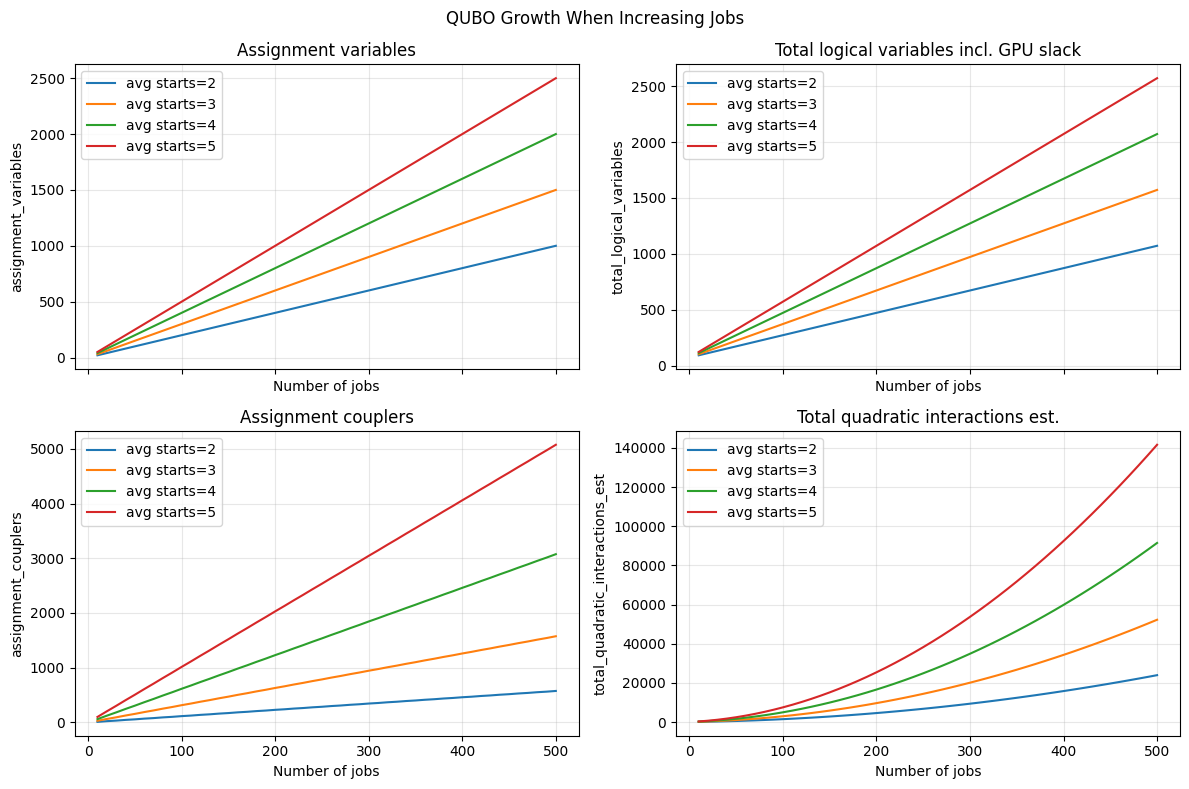

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
metrics = [
    ("assignment_variables", "Assignment variables"),
    ("total_logical_variables", "Total logical variables incl. GPU slack"),
    ("assignment_couplers", "Assignment couplers"),
    ("total_quadratic_interactions_est", "Total quadratic interactions est."),
]
for ax, (metric, title) in zip(axes.ravel(), metrics, strict=True):
    for average_starts in average_start_grid:
        data = job_scaling_df[job_scaling_df["average_starts"] == average_starts]
        ax.plot(data["num_jobs"], data[metric], label=f"avg starts={average_starts}")
    ax.set_title(title)
    ax.set_xlabel("Number of jobs")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle("QUBO Growth When Increasing Jobs")
plt.tight_layout()
plt.show()


### 13.2 Number of Clusters

Now we isolate cluster count.

Assumptions:

- 100 jobs,
- average 2 feasible starts per job,
- 24 time slots,
- clusters grow from 1 to 5,
- 70% of jobs can run in all clusters,
- 30% of jobs can run in only one cluster.

This is where QUBO growth becomes more interesting. More clusters increase assignment variables, but they increase assignment couplers faster for the 70% unrestricted jobs because each such job gets more feasible options and the assignment penalty creates pairwise interactions among those options.


In [24]:
fixed_jobs_for_cluster_scaling = 100
fixed_average_starts_for_cluster_scaling = 2
cluster_grid = list(range(1, 6))

cluster_scaling_df = pd.DataFrame([
    estimate_qubo_size(
        num_jobs=fixed_jobs_for_cluster_scaling,
        average_starts=fixed_average_starts_for_cluster_scaling,
        num_clusters=num_clusters,
        horizon_slots=24,
        gpu_capacity_per_cluster=4,
    )
    for num_clusters in cluster_grid
])
cluster_scaling_df


,num_jobs,average_starts,num_clusters,horizon_slots,gpu_capacity_per_cluster,assignment_variables,gpu_slack_variables,total_logical_variables,assignment_couplers,gpu_capacity_couplers_est,total_quadratic_interactions_est,active_assignment_vars_per_cluster_time_est
0,100,2,1,24,4,200,72,272,115,1405,1520,8.333333
1,100,2,2,24,4,340,144,484,492,2198,2690,7.083333
2,100,2,3,24,4,480,216,696,1167,3016,4183,6.666667
3,100,2,4,24,4,620,288,908,2140,3840,5980,6.458333
4,100,2,5,24,4,760,360,1120,3411,4667,8078,6.333333


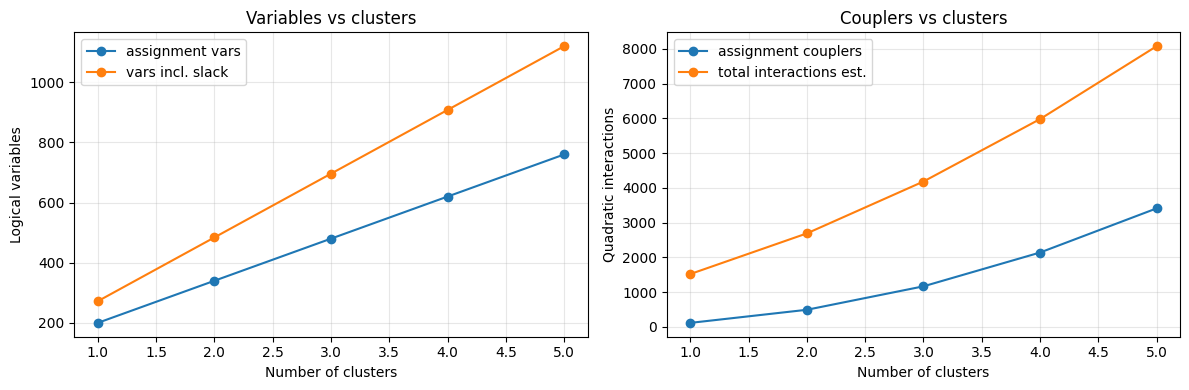

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cluster_scaling_df["num_clusters"], cluster_scaling_df["assignment_variables"], marker="o", label="assignment vars")
axes[0].plot(cluster_scaling_df["num_clusters"], cluster_scaling_df["total_logical_variables"], marker="o", label="vars incl. slack")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Logical variables")
axes[0].set_title("Variables vs clusters")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(cluster_scaling_df["num_clusters"], cluster_scaling_df["assignment_couplers"], marker="o", label="assignment couplers")
axes[1].plot(cluster_scaling_df["num_clusters"], cluster_scaling_df["total_quadratic_interactions_est"], marker="o", label="total interactions est.")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Quadratic interactions")
axes[1].set_title("Couplers vs clusters")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### 13.3 Number of Time Slots

Now we isolate horizon length.

Assumptions:

- 100 jobs,
- clusters in \(\{1,2,3,4\}\),
- horizon slots in \(\{6,12,18,24,48,72\}\),
- GPU capacity of 4 per cluster.

There are two different interpretations:

1. **Fixed flexibility:** every job keeps average 2 feasible start options, regardless of horizon length.
2. **Growing flexibility:** feasible start options grow with the horizon.

This distinction matters. If every job only has 2 feasible starts, adding more horizon slots does not create many more assignment variables. The QUBO grows when longer horizons translate into more possible start times per job.


In [26]:
time_slot_grid = [6, 12, 18, 24, 48, 72]
cluster_count_grid = [1, 2, 3, 4]
fixed_jobs_for_time_scaling = 100
fixed_average_starts_for_time_scaling = 2

rows = []
for num_clusters in cluster_count_grid:
    for horizon_slots in time_slot_grid:
        fixed_window = estimate_qubo_size(
            num_jobs=fixed_jobs_for_time_scaling,
            average_starts=fixed_average_starts_for_time_scaling,
            num_clusters=num_clusters,
            horizon_slots=horizon_slots,
            gpu_capacity_per_cluster=4,
        )
        fixed_window["window_policy"] = "fixed_avg_2"
        fixed_window["effective_average_starts"] = fixed_average_starts_for_time_scaling
        rows.append(fixed_window)

        proportional_average_starts = max(1, round(horizon_slots * fixed_average_starts_for_time_scaling / 24))
        proportional_window = estimate_qubo_size(
            num_jobs=fixed_jobs_for_time_scaling,
            average_starts=proportional_average_starts,
            num_clusters=num_clusters,
            horizon_slots=horizon_slots,
            gpu_capacity_per_cluster=4,
        )
        proportional_window["window_policy"] = "proportional_to_horizon"
        proportional_window["effective_average_starts"] = proportional_average_starts
        rows.append(proportional_window)

time_scaling_df = pd.DataFrame(rows)
time_scaling_df.head(12)


,num_jobs,average_starts,num_clusters,horizon_slots,gpu_capacity_per_cluster,assignment_variables,gpu_slack_variables,total_logical_variables,assignment_couplers,gpu_capacity_couplers_est,total_quadratic_interactions_est,active_assignment_vars_per_cluster_time_est,window_policy,effective_average_starts
0,100,2,1,6,4,200,18,218,115,3851,3966,33.333333,fixed_avg_2,2
1,100,1,1,6,4,115,18,133,15,1408,1423,19.166667,proportional_to_horizon,1
2,100,2,1,12,4,200,36,236,115,2203,2318,16.666667,fixed_avg_2,2
3,100,1,1,12,4,115,36,151,15,875,890,9.583333,proportional_to_horizon,1
4,100,2,1,18,4,200,54,254,115,1665,1780,11.111111,fixed_avg_2,2
5,100,2,1,18,4,200,54,254,115,1665,1780,11.111111,proportional_to_horizon,2
6,100,2,1,24,4,200,72,272,115,1405,1520,8.333333,fixed_avg_2,2
7,100,2,1,24,4,200,72,272,115,1405,1520,8.333333,proportional_to_horizon,2
8,100,2,1,48,4,200,144,344,115,1061,1176,4.166667,fixed_avg_2,2
9,100,4,1,48,4,400,144,544,615,2811,3426,8.333333,proportional_to_horizon,4


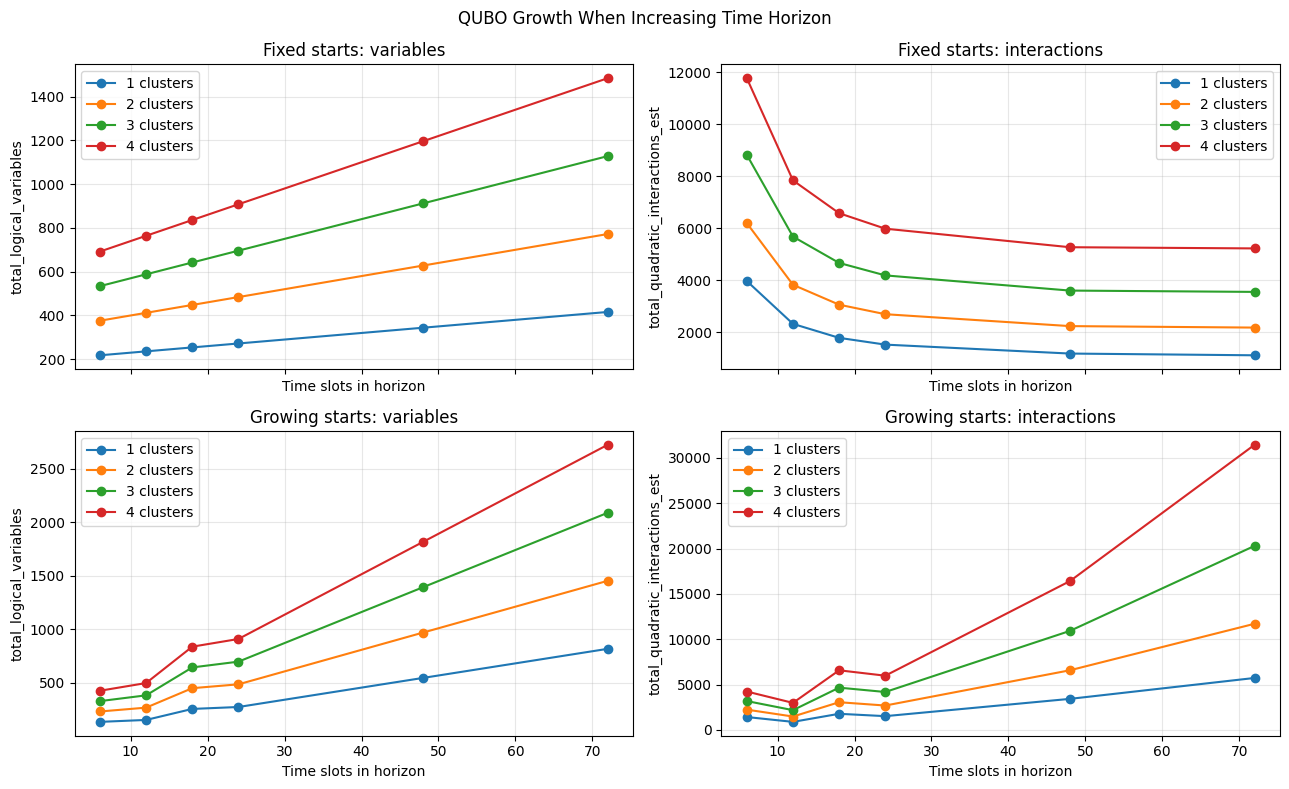

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
plot_specs = [
    ("fixed_avg_2", "total_logical_variables", "Fixed starts: variables"),
    ("fixed_avg_2", "total_quadratic_interactions_est", "Fixed starts: interactions"),
    ("proportional_to_horizon", "total_logical_variables", "Growing starts: variables"),
    ("proportional_to_horizon", "total_quadratic_interactions_est", "Growing starts: interactions"),
]
for ax, (policy, metric, title) in zip(axes.ravel(), plot_specs, strict=True):
    data_policy = time_scaling_df[time_scaling_df["window_policy"] == policy]
    for num_clusters in cluster_count_grid:
        data = data_policy[data_policy["num_clusters"] == num_clusters]
        ax.plot(data["horizon_slots"], data[metric], marker="o", label=f"{num_clusters} clusters")
    ax.set_title(title)
    ax.set_xlabel("Time slots in horizon")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle("QUBO Growth When Increasing Time Horizon")
plt.tight_layout()
plt.show()


### 13.4 Combined Growth Scenario

The previous plots isolate one dimension at a time. That is useful for explanation, but the real problem grows when multiple dimensions increase together.

Here we increase jobs, clusters, and feasible starts at the same time. This better represents why full-scale quantum execution is not currently realistic.


In [28]:
combined_rows = []
for num_jobs in [25, 50, 100, 200, 500]:
    for num_clusters in [1, 2, 3, 4, 5]:
        for average_starts in [2, 3, 4, 5]:
            combined_rows.append(estimate_qubo_size(
                num_jobs=num_jobs,
                average_starts=average_starts,
                num_clusters=num_clusters,
                horizon_slots=24,
                gpu_capacity_per_cluster=4,
            ))
combined_scaling_df = pd.DataFrame(combined_rows)
combined_scaling_df.sort_values("total_quadratic_interactions_est", ascending=False).head(10)


,num_jobs,average_starts,num_clusters,horizon_slots,gpu_capacity_per_cluster,assignment_variables,gpu_slack_variables,total_logical_variables,assignment_couplers,gpu_capacity_couplers_est,total_quadratic_interactions_est,active_assignment_vars_per_cluster_time_est
99,500,5,5,24,4,9500,360,9860,107799,400152,507951,79.166667
95,500,5,4,24,4,7750,288,8038,68840,332489,401329,80.729167
98,500,4,5,24,4,7600,360,7960,68699,260027,328726,63.333333
91,500,5,3,24,4,6000,216,6216,38733,265216,303949,83.333333
94,500,4,4,24,4,6200,288,6488,43740,215996,259736,64.583333
87,500,5,2,24,4,4250,144,4394,17478,198920,216398,88.541667
90,500,4,3,24,4,4800,216,5016,24483,172216,196699,66.666667
97,500,3,5,24,4,5700,360,6060,38499,149985,188484,47.500000
93,500,3,4,24,4,4650,288,4938,24390,124530,148920,48.437500
83,500,5,1,24,4,2500,72,2572,5075,136530,141605,104.166667


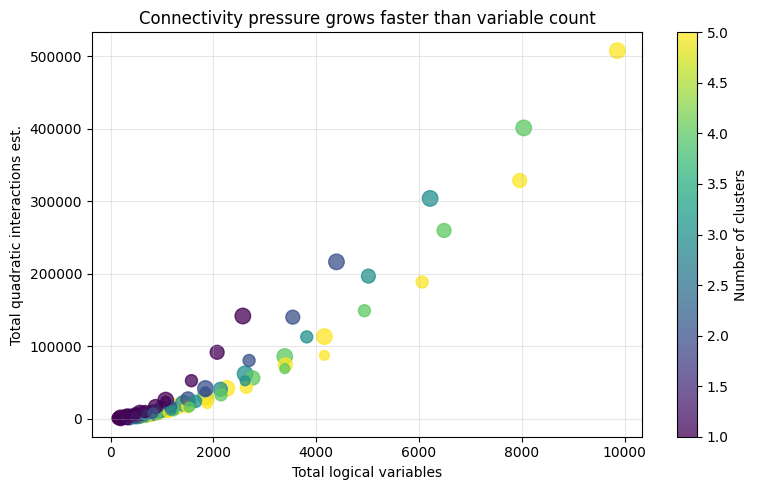

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    combined_scaling_df["total_logical_variables"],
    combined_scaling_df["total_quadratic_interactions_est"],
    c=combined_scaling_df["num_clusters"],
    s=combined_scaling_df["average_starts"] * 25,
    alpha=0.75,
)
ax.set_xlabel("Total logical variables")
ax.set_ylabel("Total quadratic interactions est.")
ax.set_title("Connectivity pressure grows faster than variable count")
ax.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Number of clusters")
plt.tight_layout()
plt.show()


### 13.5 Interpretation

The key message for the thesis is:

> The number of binary decision variables can look linear when we vary one modeling dimension at a time. That does not mean the QUBO is easy. The quadratic interactions grow much faster as jobs become compatible with more clusters and have wider feasible start windows.

This matters because D-Wave hardware must represent both:

- logical variables, and
- couplers between variables.

Dense QUBOs are harder to embed. A model with a few hundred logical variables can already become difficult if each variable interacts with many others.

Therefore, the full data-center scheduling problem is not limited only by the number of jobs. It is limited by the product of:

$$
\text{jobs} \times \text{compatible clusters} \times \text{feasible starts}
$$

and by the quadratic couplers created by assignment and capacity penalties.
